In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("ai_personalized_clothing_offers_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   user_id  age  gender   location category preferred_brand color_preference  \
0        1   56    Male    Chennai   Jacket           Levis            Beige   
1        2   46  Female  Hyderabad    Jeans            Nike            Beige   
2        3   32  Female     Mumbai   Jacket             H&M              Red   
3        4   25  Female     Mumbai    Shirt            Nike            Green   
4        5   38  Female      Delhi   Jacket            Nike            Beige   

  size  season   festival  ...  purchase_frequency  avg_order_value  \
0    M  Summer     Diwali  ...                   2           154.62   
1   XL  Spring     Diwali  ...                   8           297.76   
2    S  Autumn  Christmas  ...                   3           212.26   
3    M  Winter     Diwali  ...                   8           255.58   
4   XL  Summer        Eid  ...                   3           136.16   

   last_purchase_days  browsing_time  product_views  wishlist_items  \
0                  37

In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

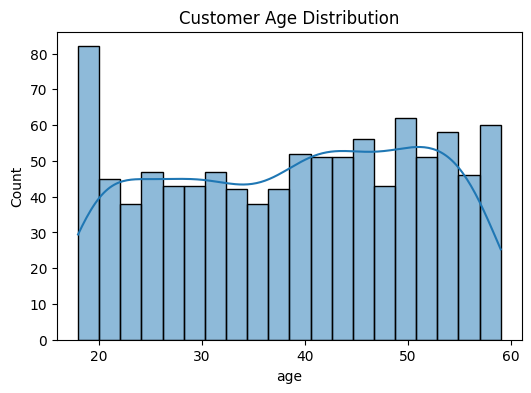

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.show()

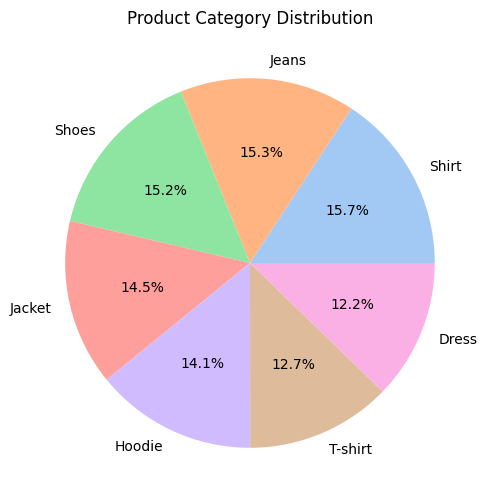

In [6]:
plt.figure(figsize=(6,6))

df["category"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)

plt.title("Product Category Distribution")
plt.ylabel("")
plt.show()

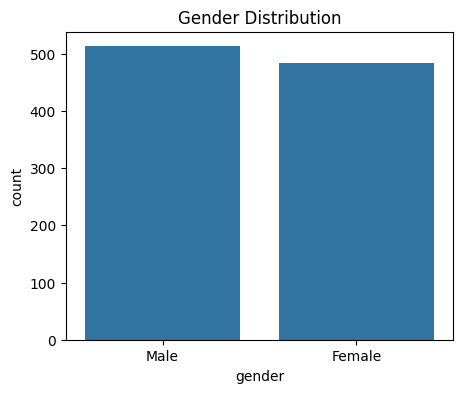

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

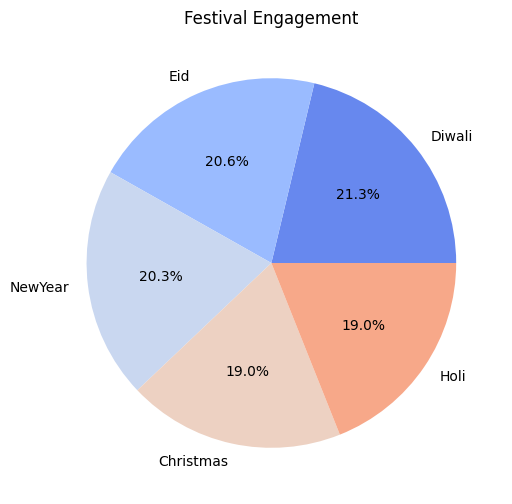

In [8]:
plt.figure(figsize=(6,6))

df["festival"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=sns.color_palette("coolwarm")
)

plt.title("Festival Engagement")
plt.ylabel("")
plt.show()

In [9]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

C:\Users\ios\AppData\Local\Temp\ipykernel_4780\4013662574.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include="object").columns:


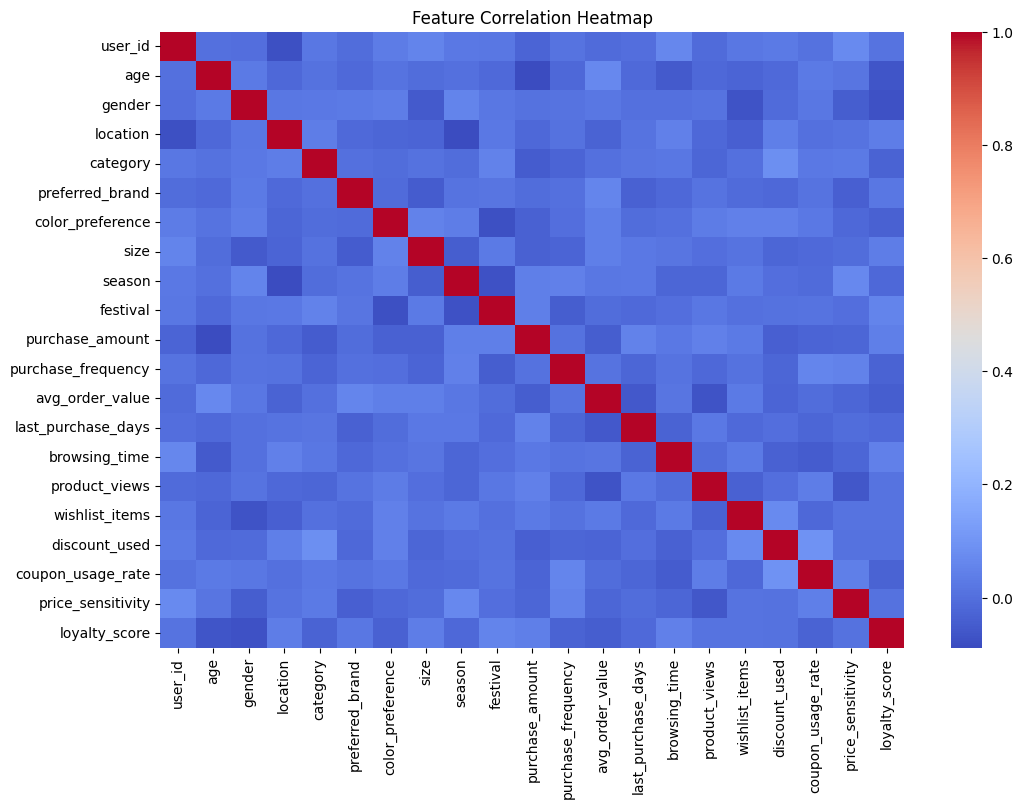

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
features = df_encoded[
[
"purchase_amount",
"purchase_frequency",
"avg_order_value",
"browsing_time",
"product_views",
"wishlist_items",
"loyalty_score"
]]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["customer_segment"] = kmeans.fit_predict(X_scaled)

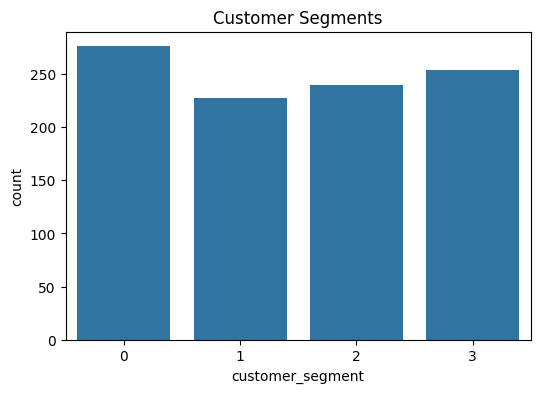

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="customer_segment", data=df)

plt.title("Customer Segments")
plt.show()

In [15]:
df_encoded["high_value_customer"] = (
    df_encoded["loyalty_score"] > 50
).astype(int)

In [16]:
X = df_encoded.drop(["high_value_customer","user_id"], axis=1)
y = df_encoded["high_value_customer"]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [18]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
import joblib

joblib.dump(model, "personalized_offer_model.pkl")

['personalized_offer_model.pkl']

In [20]:
pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       105

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



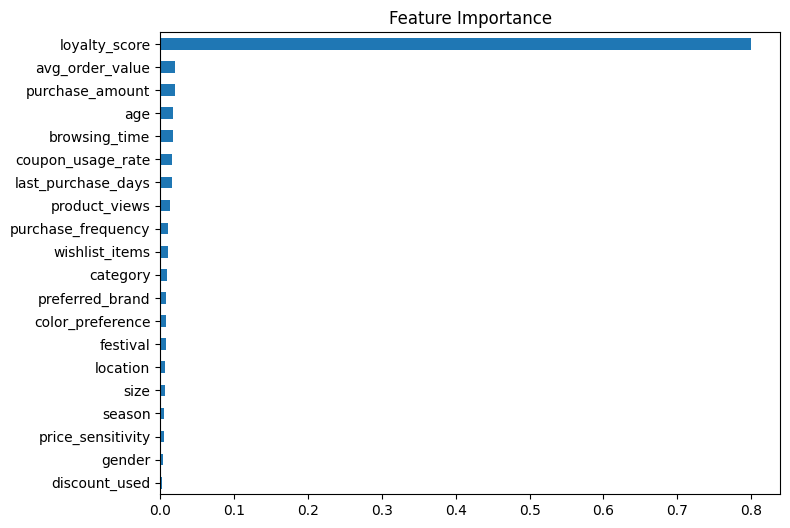

In [21]:
importance = model.feature_importances_

feat = pd.Series(
importance,
index=X.columns
).sort_values()

feat.plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance")
plt.show()

In [22]:
def generate_offer(segment,festival):
    
    if festival == "Diwali":
        return "Festive Sale: 30% Off"

    if segment == 2:
        return "Premium Customer Offer: 25% Off"

    if segment == 1:
        return "Buy 2 Get 1 Free"

    return "Standard 10% Discount"

In [23]:
user_segment = 2
festival = "Diwali"

print(generate_offer(user_segment,festival))

Festive Sale: 30% Off
